<a href="https://colab.research.google.com/github/Anand-Ambastha/QSAFIRE/blob/main/SNS_TFQKD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy matplotlib scipy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Dict, Optional, List
import logging
import time
from IPython.display import display, HTML
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

In [ ]:
@dataclass
class ChannelParameters:
    """Parameters for the quantum channel and detectors"""

    # Fiber parameters
    fiber_loss: float = 0.2  # dB/km (standard single-mode fiber at 1550nm)

    # Detector parameters (from paper)
    detector_efficiency: float = 0.8  # 80% detection efficiency
    dark_count_rate: float = 1e-11    # per pulse (paper uses 10^-11)

    # Protocol parameters
    error_correction_efficiency: float = 1.1  # f in key rate formula

    # Misalignment parameters (will be varied)
    misalignment_error: float = 0.0  # e_det in X-basis

    def __post_init__(self):
        """Validate parameters"""
        assert 0 <= self.detector_efficiency <= 1, "Detector efficiency must be between 0 and 1"
        assert self.dark_count_rate >= 0, "Dark count rate must be non-negative"
        assert self.fiber_loss > 0, "Fiber loss must be positive"
        assert self.error_correction_efficiency >= 1, "Error correction efficiency must be >= 1"
        assert 0 <= self.misalignment_error <= 0.5, "Misalignment error must be between 0 and 0.5"


@dataclass
class SimulationParameters:
    """Parameters for the simulation"""

    # Distance range
    min_distance: float = 0  # km
    max_distance: float = 800  # km
    distance_points: int = 100

    # Optimization parameters
    epsilon_range: Tuple[float, float] = (0.05, 0.95)
    mu_signal_range: Tuple[float, float] = (0.001, 0.5)
    mu_decoy_range: Tuple[float, float] = (0.0001, 0.4)

    # Grid search resolution (reduced for Colab performance)
    epsilon_steps: int = 20
    mu_signal_steps: int = 20
    mu_decoy_steps: int = 15















In [ ]:


class ChannelModel:
    """
    Implements the quantum channel model for TF-QKD

    The channel model includes:
    1. Fiber attenuation (exponential loss)
    2. Detector inefficiency
    3. Dark counts
    4. Misalignment errors
    """

    def __init__(self, params: ChannelParameters):
        """
        Initialize channel model with given parameters

        Args:
            params: ChannelParameters object containing all physical parameters
        """
        self.params = params
        logger.info(f"Initialized ChannelModel with parameters: {params}")

    def channel_transmittance(self, distance: float) -> float:
        """
        Calculate the channel transmittance (probability of photon transmission)

        Args:
            distance: Distance in km

        Returns:
            Transmittance probability (0 to 1)
        """
        # Standard fiber loss formula: T = 10^(-αL/10)
        transmittance = 10 ** (-self.params.fiber_loss * distance / 10)

        # Ensure physical bounds
        transmittance = np.clip(transmittance, 0, 1)

        return transmittance

    def total_transmittance(self, distance: float) -> float:
        """
        Calculate total transmittance including channel loss and detector efficiency

        Args:
            distance: Distance in km

        Returns:
            Total transmittance probability
        """
        channel_T = self.channel_transmittance(distance)
        total_T = channel_T * self.params.detector_efficiency

        return total_T

    def vacuum_yield(self) -> float:
        """
        Calculate the yield (counting rate) for vacuum states

        In the paper: Y₀ = 2 * dark_count_rate
        (Two detectors, each with dark count probability p_dark)

        Returns:
            Vacuum yield probability
        """
        # Each detector has dark count probability p_dark
        # Yield for vacuum: probability that at least one detector clicks
        p_dark = self.params.dark_count_rate

        # For vacuum: Y₀ = 1 - (1-p_dark)^2 ≈ 2*p_dark
        yield_vacuum = 1 - (1 - p_dark) ** 2

        return yield_vacuum

    def intensity_yield(self, intensity: float, distance: float) -> float:
        """
        Calculate the yield (counting rate) for a given intensity

        Args:
            intensity: μ (mean photon number)
            distance: Distance in km

        Returns:
            Yield probability
        """
        eta = self.total_transmittance(distance)
        Y0 = self.vacuum_yield()

        # Formula: Y_μ = 1 - (1 - Y0) * exp(-ημ)
        # This includes both signal and dark count contributions
        yield_intensity = 1 - (1 - Y0) * np.exp(-eta * intensity)

        # Ensure physical bounds
        yield_intensity = np.clip(yield_intensity, 0, 1)

        return yield_intensity

    def gain(self, intensity: float, distance: float) -> float:
        """
        Calculate the gain (counting rate including source probability)

        For a coherent state with intensity μ:
        Gain = Y_μ * (1 - e^{-μ}) for single-photon terms etc.
        But for total gain: G_μ = Y_μ * (1 - e^{-μ})

        Args:
            intensity: Mean photon number
            distance: Distance in km

        Returns:
            Gain probability
        """
        Y_mu = self.intensity_yield(intensity, distance)

        # Probability of sending at least one photon
        prob_nonzero = 1 - np.exp(-intensity)

        gain = Y_mu * prob_nonzero

        return gain

    def qber_x_basis(self, intensity: float, distance: float) -> float:
        """
        Calculate the Quantum Bit Error Rate (QBER) in X-basis

        In the paper: E_μ^X = e_det + (1 - e_det)(1 - e^{-ημ})/2

        Args:
            intensity: Mean photon number
            distance: Distance in km

        Returns:
            X-basis error rate
        """
        eta = self.total_transmittance(distance)
        e_det = self.params.misalignment_error

        # Error rate formula from the paper
        error_rate = e_det + (1 - e_det) * (1 - np.exp(-eta * intensity)) / 2

        # Ensure physical bounds
        error_rate = np.clip(error_rate, 0, 0.5)

        return error_rate

    def qber_z_basis(self) -> float:
        """
        Calculate the QBER in Z-basis

        In SNS protocol, Z-basis has no misalignment error
        because there is no single-photon interference

        Returns:
            Z-basis error rate (always 0 for SNS)
        """
        return 0.0


In [ ]:


class DetectorModel:
    """
    Implements the detector model including:
    1. Detection efficiency
    2. Dark counts
    3. Dead time (simplified)
    """

    def __init__(self, efficiency: float, dark_count: float):
        """
        Initialize detector model

        Args:
            efficiency: Detection efficiency (0 to 1)
            dark_count: Dark count rate per pulse
        """
        self.efficiency = efficiency
        self.dark_count = dark_count
        logger.info(f"Initialized DetectorModel with η={efficiency}, d={dark_count}")

    def detection_probability(self, photon_number: int, eta_channel: float) -> float:
        """
        Calculate probability of detecting a given number of photons

        Args:
            photon_number: Number of incident photons
            eta_channel: Channel transmittance

        Returns:
            Detection probability
        """
        if photon_number == 0:
            # Only dark counts for vacuum
            return self.dark_count
        else:
            # At least one photon detected or dark count
            eta_total = eta_channel * self.efficiency
            prob_detect = 1 - (1 - self.dark_count) * (1 - eta_total) ** photon_number
            return prob_detect

    def dark_count_probability(self) -> float:
        """Return the dark count probability per pulse"""
        return self.dark_count

In [ ]:


class PhotonStatistics:
    """
    Implements photon number statistics for coherent states
    and two-mode states used in SNS-TF-QKD
    """

    @staticmethod
    def poisson_probability(intensity: float, n: int) -> float:
        """
        Calculate Poisson probability for n photons

        Args:
            intensity: Mean photon number μ
            n: Number of photons

        Returns:
            Probability P(n|μ) = e^{-μ} μ^n / n!
        """
        if n < 0:
            return 0.0
        return np.exp(-intensity) * (intensity ** n) / np.math.factorial(n)

    @staticmethod
    def two_mode_probability(intensity: float, n: int) -> float:
        """
        Calculate probability for two-mode state with total n photons

        For two modes each with mean photon number μ:
        P(n) = e^{-2μ} (2μ)^n / n!

        Args:
            intensity: Mean photon number per mode μ
            n: Total photon number

        Returns:
            Probability P(n) for two-mode state
        """
        if n < 0:
            return 0.0
        return np.exp(-2 * intensity) * (2 * intensity) ** n / np.math.factorial(n)

    @staticmethod
    def p0(intensity: float) -> float:
        """Probability of zero photons in two-mode state"""
        return np.exp(-2 * intensity)

    @staticmethod
    def p1(intensity: float) -> float:
        """Probability of exactly one photon in two-mode state"""
        return 2 * intensity * np.exp(-2 * intensity)

    @staticmethod
    def p2(intensity: float) -> float:
        """Probability of exactly two photons in two-mode state"""
        return 2 * intensity**2 * np.exp(-2 * intensity)

In [ ]:


class ChannelVisualizer:
    """Visualization tools for channel models"""

    @staticmethod
    def plot_channel_transmittance(channel: ChannelModel, distances: np.ndarray,
                                   title: str = "Channel Transmittance vs Distance"):
        """Plot channel transmittance vs distance"""
        fig, ax = plt.subplots(figsize=(12, 7))

        T_channel = [channel.channel_transmittance(d) for d in distances]
        T_total = [channel.total_transmittance(d) for d in distances]

        ax.semilogy(distances, T_channel, 'b-', linewidth=2.5, label='Channel Transmittance')
        ax.semilogy(distances, T_total, 'r-', linewidth=2.5, label='Total Transmittance (including detector)')

        # Add horizontal line at 1
        ax.axhline(y=1, color='gray', linestyle=':', alpha=0.5)

        # Add vertical lines at key distances
        for d in [100, 200, 300, 400, 500, 600, 700, 800]:
            if d <= distances[-1]:
                ax.axvline(x=d, color='gray', linestyle='--', alpha=0.2)
                ax.text(d, ax.get_ylim()[1]*0.9, f'{d}km', rotation=90, fontsize=8, alpha=0.5)

        ax.set_xlabel('Distance (km)', fontsize=14)
        ax.set_ylabel('Transmittance (log scale)', fontsize=14)
        ax.set_title(title, fontsize=16, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=12)
        ax.set_ylim([1e-20, 2])

        # Add text box with parameters
        textstr = f'Loss: {channel.params.fiber_loss} dB/km\nη_det: {channel.params.detector_efficiency*100}%'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=props)

        return fig, ax

    @staticmethod
    def plot_yields(channel: ChannelModel, intensities: np.ndarray, distance: float,
                    title: str = None):
        """Plot yield vs intensity for a fixed distance"""
        if title is None:
            title = f'Yield vs Intensity at {distance} km'

        fig, ax = plt.subplots(figsize=(12, 7))

        yields = [channel.intensity_yield(mu, distance) for mu in intensities]

        ax.plot(intensities, yields, 'g-', linewidth=2.5, label=f'Y_μ at {distance} km')

        # Mark vacuum yield
        Y0 = channel.vacuum_yield()
        ax.axhline(y=Y0, color='gray', linestyle='--', linewidth=2, label=f'Y₀ = {Y0:.2e}')

        # Add vertical line at optimal intensity (for reference)
        ax.axvline(x=0.1, color='purple', linestyle=':', alpha=0.5, label='μ = 0.1')

        ax.set_xlabel('Intensity μ', fontsize=14)
        ax.set_ylabel('Yield Y_μ', fontsize=14)
        ax.set_title(title, fontsize=16, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=12)

        # Add text box
        textstr = f'Distance: {distance} km\nDark count: {channel.params.dark_count_rate:.1e}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=props)

        return fig, ax

    @staticmethod
    def plot_qber(channel: ChannelModel, intensities: np.ndarray, distance: float,
                  title: str = None):
        """Plot QBER vs intensity for X-basis"""
        if title is None:
            title = f'X-basis QBER vs Intensity at {distance} km'

        fig, ax = plt.subplots(figsize=(12, 7))

        error_rates = [channel.qber_x_basis(mu, distance) for mu in intensities]

        ax.plot(intensities, error_rates, 'm-', linewidth=2.5, label=f'X-basis QBER at {distance} km')

        # Show misalignment limit
        e_det = channel.params.misalignment_error
        ax.axhline(y=e_det, color='red', linestyle='--', linewidth=2, label=f'e_det = {e_det:.3f}')

        # Add horizontal line at 0.5 (maximum)
        ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Maximum QBER')

        ax.set_xlabel('Intensity μ', fontsize=14)
        ax.set_ylabel('QBER', fontsize=14)
        ax.set_title(title, fontsize=16, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=12)
        ax.set_ylim([-0.02, 0.52])

        # Add text box
        textstr = f'Distance: {distance} km\nMisalignment: {e_det*100:.0f}%'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=props)

        return fig, ax

    @staticmethod
    def plot_comparison_different_misalignments(channel_params: ChannelParameters,
                                                distances: np.ndarray):
        """Plot QBER for different misalignment errors"""
        fig, ax = plt.subplots(figsize=(14, 8))

        misalignments = [0.0, 0.15, 0.25, 0.35, 0.45]
        colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(misalignments)))

        intensity = 0.1  # Fixed intensity for comparison

        for i, e_det in enumerate(misalignments):
            params_temp = ChannelParameters(
                fiber_loss=channel_params.fiber_loss,
                detector_efficiency=channel_params.detector_efficiency,
                dark_count_rate=channel_params.dark_count_rate,
                misalignment_error=e_det
            )
            channel_temp = ChannelModel(params_temp)

            qber = [channel_temp.qber_x_basis(intensity, d) for d in distances]
            ax.plot(distances, qber, color=colors[i], linewidth=2.5,
                   label=f'e_det = {e_det*100:.0f}%')

        # Add horizontal lines at key values
        for e_det in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
            ax.axhline(y=e_det, color='gray', linestyle=':', alpha=0.3)

        ax.set_xlabel('Distance (km)', fontsize=14)
        ax.set_ylabel('X-basis QBER', fontsize=14)
        ax.set_title(f'X-basis QBER vs Distance for Different Misalignment Errors (μ={intensity})',
                     fontsize=16, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=12)
        ax.set_ylim([-0.02, 0.52])

        return fig, ax

In [ ]:


def run_channel_simulation():
    """Main function to run the channel simulation in Colab"""

    print("=" * 70)
    print("PHASE 1: Basic Channel Modeling for SNS-TF-QKD")
    print("=" * 70)
    print("\n Simulating quantum channel for Twin-Field QKD")
    print("Based on Wang et al. (2018) - Nature 557, 400-403")
    print("=" * 70)

    # 1. Initialize parameters
    print("\n[1] Initializing channel parameters...")
    params = ChannelParameters(
        fiber_loss=0.2,
        detector_efficiency=0.8,
        dark_count_rate=1e-11,
        error_correction_efficiency=1.1,
        misalignment_error=0.0
    )
    print(f" Parameters configured: {params}")

    # 2. Create channel model
    print("\n[2] Creating channel model...")
    channel = ChannelModel(params)
    print(" Channel model created successfully")

    # 3. Generate key metrics
    print("\n[3] Calculating key channel metrics...")

    distances = np.array([0, 100, 200, 300, 400, 500, 600, 700, 800])

    print("\n Channel transmittance for different distances:")
    print("-" * 60)
    print(f"{'Distance':<12} {'Channel T':<14} {'Total T':<14} {'Loss (dB)':<12}")
    print("-" * 60)
    for d in distances:
        T = channel.channel_transmittance(d)
        T_total = channel.total_transmittance(d)
        loss_db = -10 * np.log10(T) if T > 0 else float('inf')
        print(f"{d:3d} km       {T:<14.2e} {T_total:<14.2e} {loss_db:<12.1f}")

    print(f"\n🔦 Vacuum yield: Y₀ = {channel.vacuum_yield():.2e}")

    # 4. Test yields for different intensities
    print("\n[4] Testing yields for different intensities at 500 km:")
    print("-" * 60)
    intensities = np.array([0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0])
    print(f"{'Intensity μ':<14} {'Yield Y_μ':<14} {'Gain G_μ':<14} {'QBER X':<14}")
    print("-" * 60)
    for mu in intensities:
        Y = channel.intensity_yield(mu, 500)
        G = channel.gain(mu, 500)
        E = channel.qber_x_basis(mu, 500)
        print(f"{mu:<14.3f} {Y:<14.6e} {G:<14.6e} {E:<14.6f}")

    # 5. Test different misalignment errors
    print("\n[5] Testing different misalignment errors at 500 km (μ=0.1):")
    print("-" * 60)
    misalignment_values = [0.0, 0.05, 0.15, 0.25, 0.35, 0.45]
    print(f"{'e_det':<12} {'QBER X':<14} {'Note':<20}")
    print("-" * 60)
    for e_det in misalignment_values:
        params_temp = ChannelParameters(misalignment_error=e_det)
        channel_temp = ChannelModel(params_temp)
        E = channel_temp.qber_x_basis(0.1, 500)
        note = "High" if E > 0.3 else "OK"
        print(f"{e_det:<12.2f} {E:<14.6f} {note}")

    # 6. Create comprehensive visualizations
    print("\n[6] Generating visualizations...")
    print("Creating plots...")

    # Plot 1: Channel transmittance
    dist_array = np.linspace(0, 800, 500)
    fig1, ax1 = ChannelVisualizer.plot_channel_transmittance(
        channel, dist_array,
        title="Channel Transmittance vs Distance (SNS-TF-QKD)"
    )

    # Plot 2: Yield vs intensity
    mu_array = np.linspace(0.001, 1.0, 200)
    fig2, ax2 = ChannelVisualizer.plot_yields(
        channel, mu_array, 500,
        title=f"Yield vs Intensity at 500 km (Y₀ = {channel.vacuum_yield():.2e})"
    )

    # Plot 3: QBER vs intensity
    fig3, ax3 = ChannelVisualizer.plot_qber(
        channel, mu_array, 500,
        title=f"X-basis QBER vs Intensity at 500 km (e_det = {params.misalignment_error*100:.0f}%)"
    )

    # Plot 4: Comparison of misalignment errors
    fig4, ax4 = ChannelVisualizer.plot_comparison_different_misalignments(
        params, dist_array
    )

    # 7. Summary statistics
    print("\n[7] Summary Statistics:")
    print("=" * 60)
    print(f"🔹 Fiber loss coefficient: {params.fiber_loss} dB/km")
    print(f"🔹 Detector efficiency: {params.detector_efficiency*100}%")
    print(f"🔹 Dark count rate: {params.dark_count_rate:.1e} per pulse")
    print(f"🔹 Vacuum yield: {channel.vacuum_yield():.2e}")
    print(f"🔹 Total transmittance at 500 km: {channel.total_transmittance(500):.2e}")
    print(f"🔹 Channel loss at 500 km: {-10*np.log10(channel.channel_transmittance(500)):.1f} dB")
    print(f"🔹 X-basis QBER at μ=0.1, 500 km: {channel.qber_x_basis(0.1, 500):.6f}")
    print("=" * 60)

    print("\n✅ Phase 1 completed successfully!")
    print("📈 Plots displayed below. You can interact with them in Colab.")

    # Display all plots
    plt.tight_layout()
    plt.show()

    return channel, params, [fig1, fig2, fig3, fig4]



In [ ]:
def run_tests():
    """Run simple unit tests for the channel model"""

    print("\n" + "=" * 60)
    print("🧪 Running Unit Tests")
    print("=" * 60)

    params = ChannelParameters()
    channel = ChannelModel(params)

    tests_passed = 0
    total_tests = 0

        # Test 1: Channel transmittance
    print("\nTest 1: Channel transmittance")
    try:
        # Test 1a: At 0 km
        assert channel.channel_transmittance(0) == 1.0, "Transmittance at 0 km should be 1"
        print("  T(0) = 1")

        # Test 1b: At 100 km
        T_100 = channel.channel_transmittance(100)
        expected_100 = 10**(-2)  # 0.01
        assert abs(T_100 - expected_100) < 1e-15, f"T(100) should be ~0.01, got {T_100}"
        print(f" T(100) = {T_100:.2e}")

        # Test 1c: At 1000 km (use tolerance for floating point)
        T_1000 = channel.channel_transmittance(1000)
        expected_1000 = 10**(-20)  # 1e-20
        # Use relative tolerance for very sm
        assert abs(T_1000 - expected_1000) / expected_1000 < 1e-12, \
        f"T(1000) should be ~1e-20, got {T_1000:.2e}"
        print(f" T(1000) = {T_1000:.2e}")

        tests_passed += 1
    except AssertionError as e:
        print(f" Test failed: {e}")
    total_tests += 1

    # Test 2: Vacuum yield
    print("\nTest 2: Vacuum yield")
    try:
        Y0 = channel.vacuum_yield()
        assert 0 <= Y0 <= 1, "Vacuum yield should be between 0 and 1"
        assert Y0 > 0, "Vacuum yield should be positive due to dark counts"
        print(f" Y₀ = {Y0:.2e}")
        tests_passed += 1
    except AssertionError as e:
        print(f" Test failed: {e}")
    total_tests += 1

    # Test 3: Intensity yield
    print("\nTest 3: Intensity yield")
    try:
        for mu in [0.001, 0.01, 0.1, 0.5]:
            Y = channel.intensity_yield(mu, 500)
            assert 0 <= Y <= 1, f"Yield for μ={mu} should be between 0 and 1"
        print("Yield tests passed")
        tests_passed += 1
    except AssertionError as e:
        print(f" Test failed: {e}")
    total_tests += 1

    # Test 4: QBER
    print("\nTest 4: X-basis QBER")
    try:
        for mu in [0.001, 0.01, 0.1, 0.5]:
            E = channel.qber_x_basis(mu, 500)
            assert 0 <= E <= 0.5, f"QBER for μ={mu} should be between 0 and 0.5"
        print("QBER tests passed")
        tests_passed += 1
    except AssertionError as e:
        print(f"❌ Test failed: {e}")
    total_tests += 1

    print(f"\n Tests passed: {tests_passed}/{total_tests}")

    if tests_passed == total_tests:
        print(" All tests passed!")
        return True
    else:
        print("Some tests failed. Please check the implementation.")
        return False




In [ ]:
# ============================================================================
# PART 8: Advanced Analysis Functions
# ============================================================================

def analyze_channel_performance():
    """Perform comprehensive channel analysis"""

    print("\n" + "=" * 70)
    print("Advanced Channel Performance Analysis")
    print("=" * 70)

    params = ChannelParameters()
    channel = ChannelModel(params)

    distances = np.linspace(0, 800, 9)
    intensities = np.logspace(-3, 0, 20)

    yield_matrix = np.zeros((len(intensities), len(distances)))
    qber_matrix = np.zeros((len(intensities), len(distances)))

    for i, mu in enumerate(intensities):
        for j, d in enumerate(distances):
            yield_matrix[i, j] = channel.intensity_yield(mu, d)
            qber_matrix[i, j] = channel.qber_x_basis(mu, d)


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    im1 = ax1.imshow(yield_matrix, aspect='auto', origin='lower',
                     extent=[distances[0], distances[-1], np.log10(intensities[0]), np.log10(intensities[-1])],
                     cmap='viridis')
    ax1.set_xlabel('Distance (km)', fontsize=12)
    ax1.set_ylabel('log10(Intensity μ)', fontsize=12)
    ax1.set_title('Yield Y_μ Heatmap', fontsize=14, fontweight='bold')
    plt.colorbar(im1, ax=ax1, label='Yield')

    im2 = ax2.imshow(qber_matrix, aspect='auto', origin='lower',
                     extent=[distances[0], distances[-1], np.log10(intensities[0]), np.log10(intensities[-1])],
                     cmap='RdYlGn_r', vmin=0, vmax=0.5)
    ax2.set_xlabel('Distance (km)', fontsize=12)
    ax2.set_ylabel('log10(Intensity μ)', fontsize=12)
    ax2.set_title('X-basis QBER Heatmap', fontsize=14, fontweight='bold')
    plt.colorbar(im2, ax=ax2, label='QBER')

    plt.tight_layout()
    plt.show()

    return yield_matrix, qber_matrix






In [ ]:


def interactive_analysis():
    """Create interactive widgets for Colab (requires ipywidgets)"""
    try:
        import ipywidgets as widgets
        from IPython.display import display

        print("Loading interactive widgets...")

        # Create widgets
        distance_slider = widgets.FloatSlider(
            value=500, min=0, max=800, step=10,
            description='Distance (km):',
            style={'description_width': 'initial'}
        )

        intensity_slider = widgets.FloatSlider(
            value=0.1, min=0.001, max=1.0, step=0.001,
            description='Intensity μ:',
            style={'description_width': 'initial'}
        )

        misalignment_slider = widgets.FloatSlider(
            value=0.0, min=0.0, max=0.5, step=0.01,
            description='Misalignment e_det:',
            style={'description_width': 'initial'}
        )

        output = widgets.Output()

        def update_plots(distance, intensity, misalignment):
            with output:
                output.clear_output(wait=True)

                params = ChannelParameters(misalignment_error=misalignment)
                channel = ChannelModel(params)

                Y = channel.intensity_yield(intensity, distance)
                E = channel.qber_x_basis(intensity, distance)
                G = channel.gain(intensity, distance)

                print(f"Results at {distance} km, μ={intensity:.3f}, e_det={misalignment:.3f}")
                print("=" * 50)
                print(f"Yield Y_μ:     {Y:.6e}")
                print(f"Gain G_μ:      {G:.6e}")
                print(f"X-basis QBER:  {E:.6f}")
                print("=" * 50)


                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

                dist_range = np.linspace(0, 800, 100)
                yields = [channel.intensity_yield(intensity, d) for d in dist_range]
                ax1.plot(dist_range, yields, 'b-', linewidth=2)
                ax1.axvline(x=distance, color='red', linestyle='--', alpha=0.5)
                ax1.set_xlabel('Distance (km)')
                ax1.set_ylabel('Yield')
                ax1.set_title(f'Yield vs Distance (μ={intensity:.3f})')
                ax1.grid(True, alpha=0.3)

                # QBER vs distance
                qbers = [channel.qber_x_basis(intensity, d) for d in dist_range]
                ax2.plot(dist_range, qbers, 'm-', linewidth=2)
                ax2.axvline(x=distance, color='red', linestyle='--', alpha=0.5)
                ax2.axhline(y=misalignment, color='gray', linestyle='--', alpha=0.5, label=f'e_det={misalignment:.3f}')
                ax2.set_xlabel('Distance (km)')
                ax2.set_ylabel('QBER')
                ax2.set_title(f'X-basis QBER vs Distance (μ={intensity:.3f})')
                ax2.grid(True, alpha=0.3)
                ax2.legend()

                plt.tight_layout()
                plt.show()

        widgets.interactive(update_plots,
                           distance=distance_slider,
                           intensity=intensity_slider,
                           misalignment=misalignment_slider)

        display(distance_slider, intensity_slider, misalignment_slider, output)

    except ImportError:
        print(" ipywidgets not available. Install with: !pip install ipywidgets")
        print("Running static analysis instead...")
        run_channel_simulation()


 STARTING SNS-TF-QKD CHANNEL MODEL SIMULATION
PHASE 1: Basic Channel Modeling for SNS-TF-QKD

 Simulating quantum channel for Twin-Field QKD
Based on Wang et al. (2018) - Nature 557, 400-403

[1] Initializing channel parameters...
 Parameters configured: ChannelParameters(fiber_loss=0.2, detector_efficiency=0.8, dark_count_rate=1e-11, error_correction_efficiency=1.1, misalignment_error=0.0)

[2] Creating channel model...
 Channel model created successfully

[3] Calculating key channel metrics...

 Channel transmittance for different distances:
------------------------------------------------------------
Distance     Channel T      Total T        Loss (dB)   
------------------------------------------------------------
  0 km       1.00e+00       8.00e-01       -0.0        
100 km       1.00e-02       8.00e-03       20.0        
200 km       1.00e-04       8.00e-05       40.0        
300 km       1.00e-06       8.00e-07       60.0        
400 km       1.00e-08       8.00e-09       80.0 

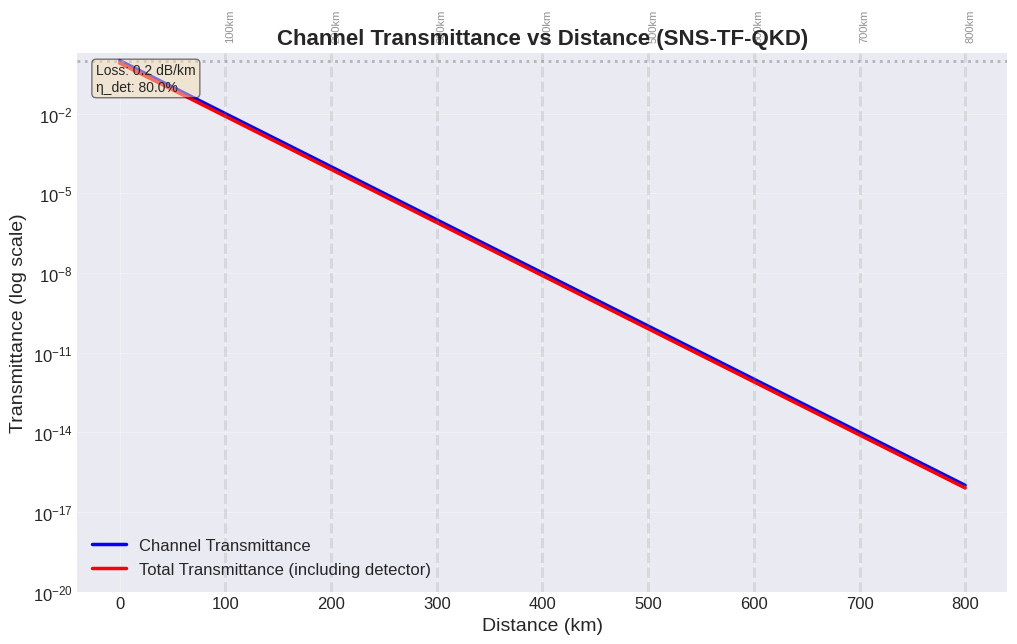

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


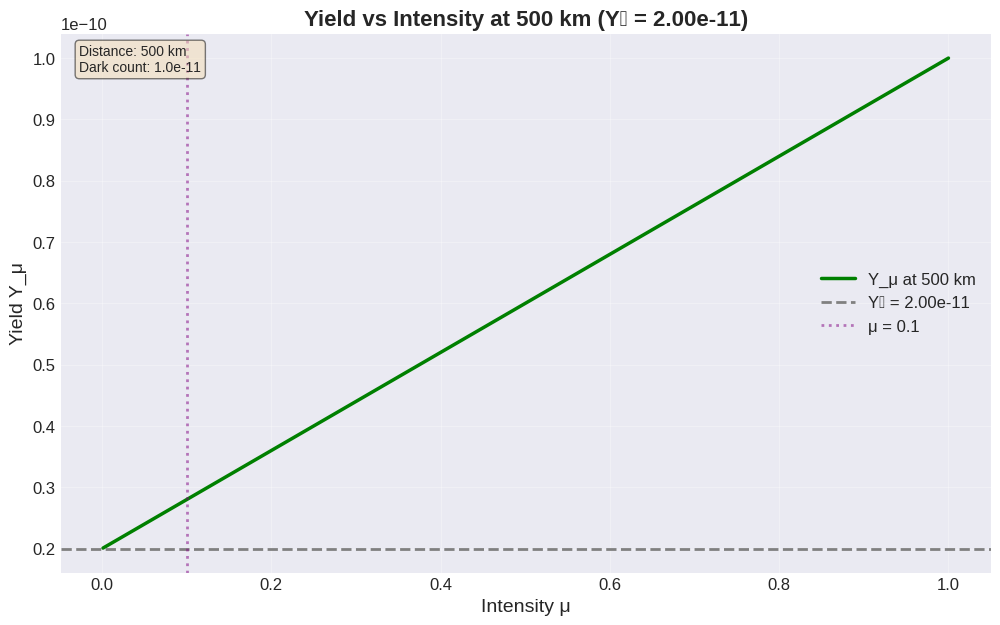

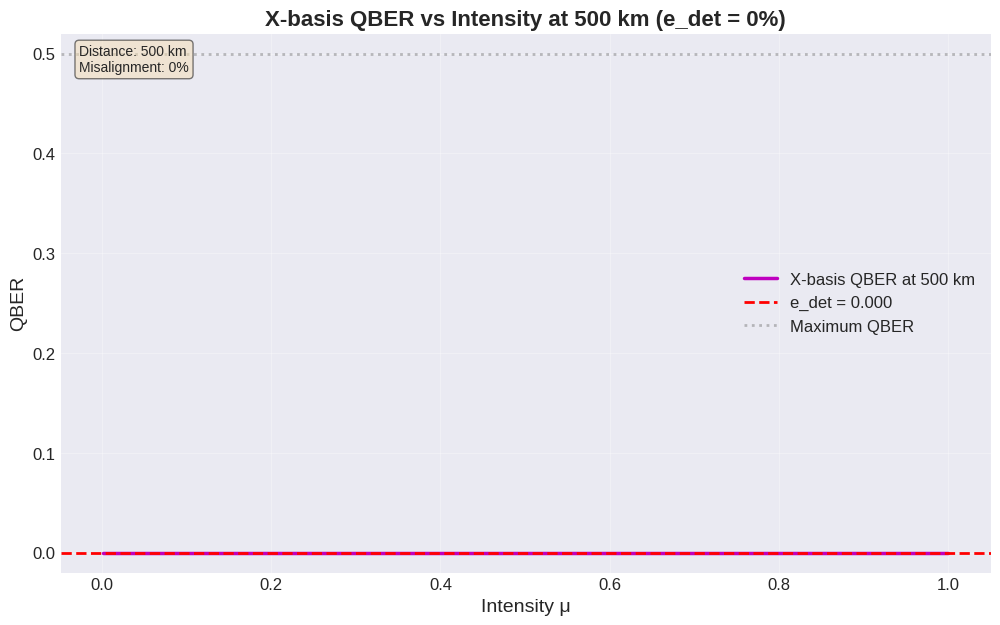

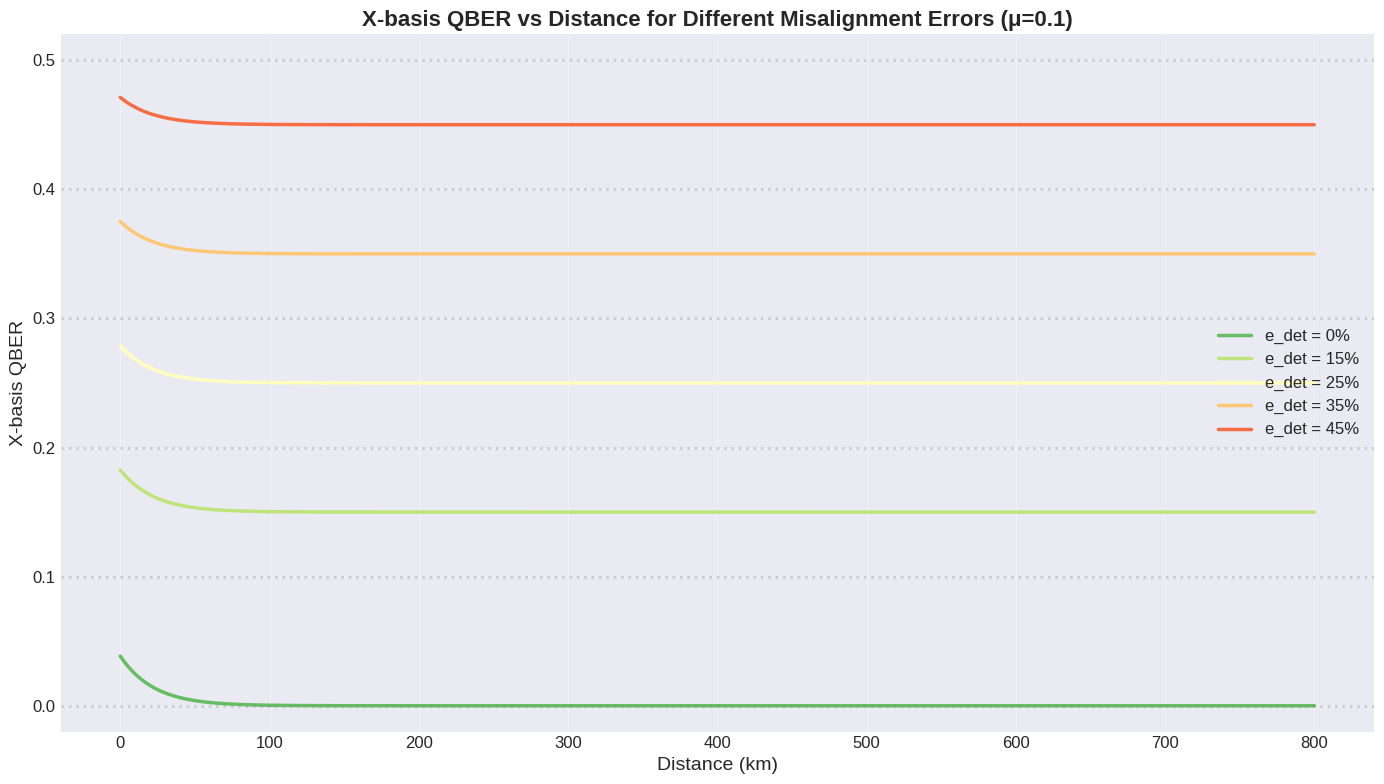


🧪 Running Unit Tests

Test 1: Channel transmittance
  T(0) = 1
 T(100) = 1.00e-02
 T(1000) = 1.00e-20

Test 2: Vacuum yield
 Y₀ = 2.00e-11

Test 3: Intensity yield
Yield tests passed

Test 4: X-basis QBER
QBER tests passed

 Tests passed: 4/4
 All tests passed!

Advanced Channel Performance Analysis


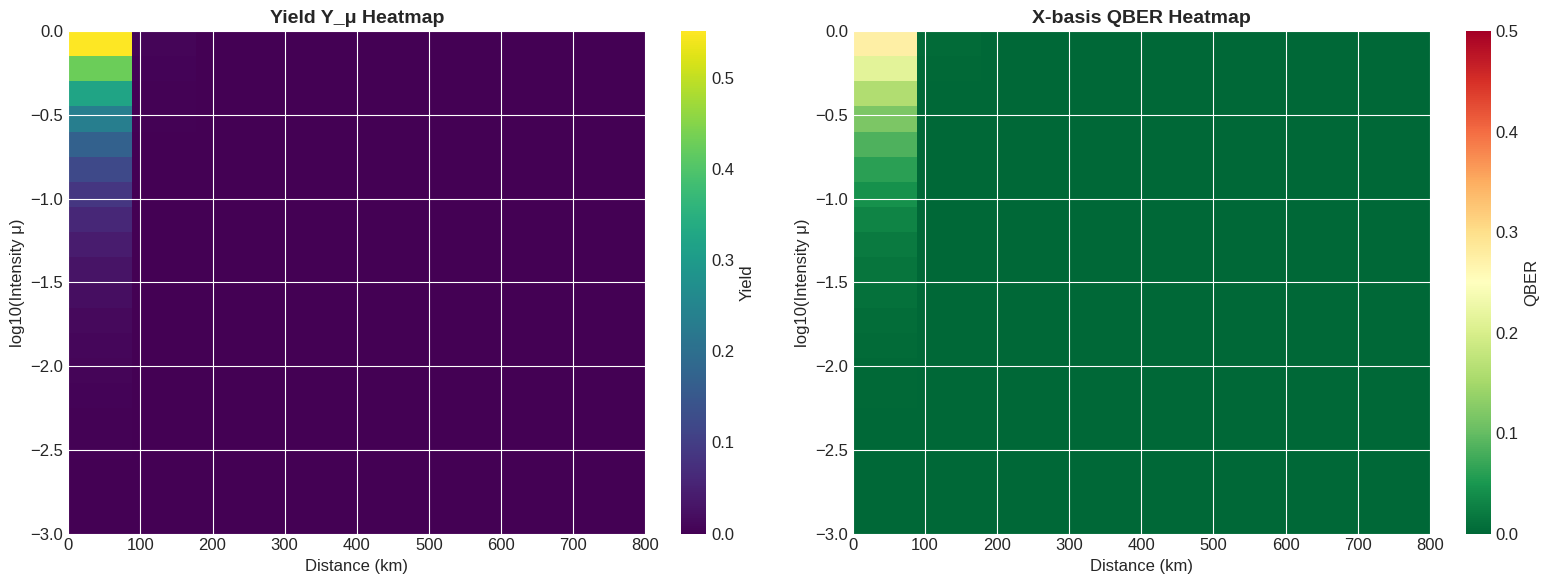


To run interactive analysis, call: interactive_analysis()

 PHASE 1 COMPLETED SUCCESSFULLY!


In [ ]:
def main():

    print(" SNS-TF-QKD CHANNEL MODEL")
    print("=" * 70)
    channel, params, figs = run_channel_simulation()
    tests_passed = run_tests()
    yield_matrix, qber_matrix = analyze_channel_performance()

    print("\nTo run interactive analysis, call: interactive_analysis()")

    return channel, params


if __name__ == "__main__":
    channel, params = main()